In [1]:
from utils.dataloader import *
import os
import pprint

Currect path: /orcd/home/002/nithidan/6-s058/6.s058-Project


In [2]:
# No / at the end
DATASET_PATH = '/home/nithidan/orcd/pool/6-s058'

In [3]:
m_name = 'Akuhamu'
page_num = 1
f'{DATASET_PATH}/Manga109/images/{m_name}/{page_num:03d}.jpg'

'/home/nithidan/orcd/pool/6-s058/Manga109/images/Akuhamu/001.jpg'

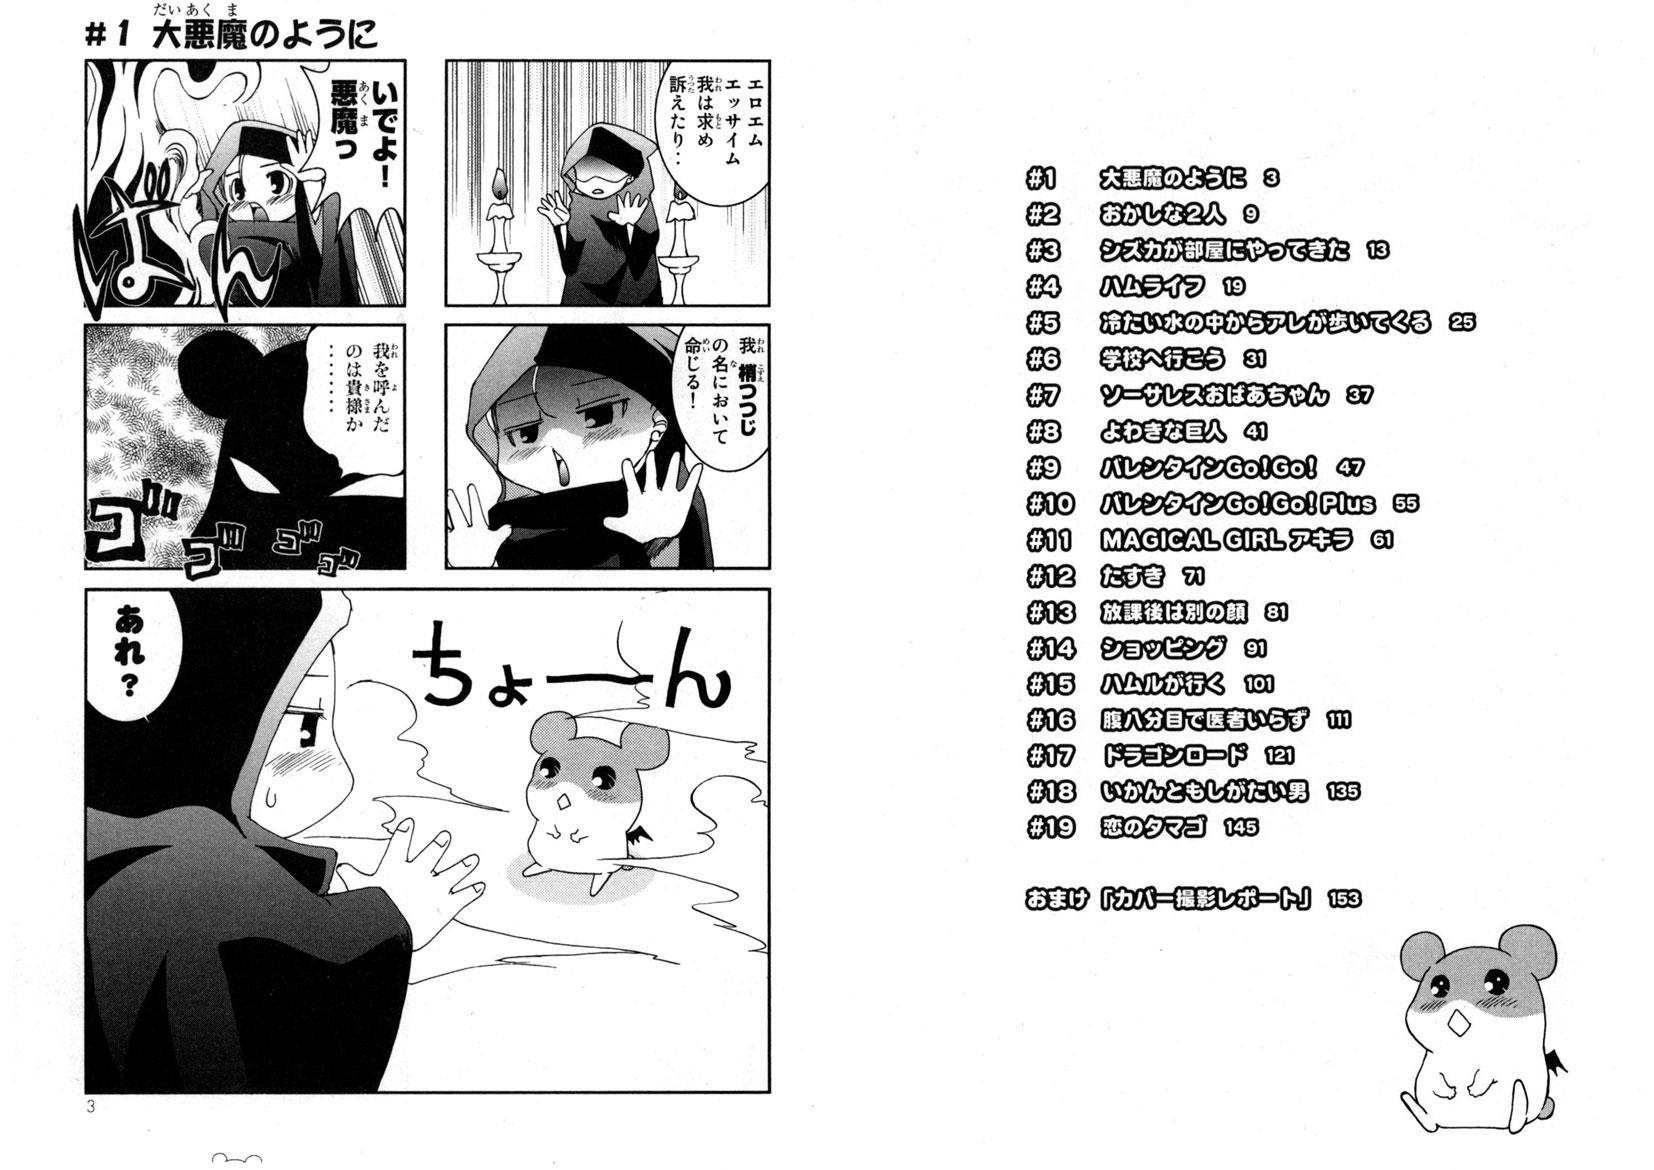

In [4]:
retrieve_page(DATASET_PATH, 'Akuhamu', 1)

In [5]:
annotations = annotation_loader(DATASET_PATH, 'Akuhamu')

characters_id, characters_name = get_character_list(annotations)
print(characters_id[:3])


['00002d03', '00002d05', '00002db8']


In [6]:
pprint.pprint(annotations)

{'book': {'@title': 'Akuhamu',
          'characters': {'character': [{'@id': '00002d03',
                                        '@name': 'ハムル・キンスキー２世'},
                                       {'@id': '00002d05', '@name': '梢つつじ'},
                                       {'@id': '00002db8', '@name': 'シズカ'},
                                       {'@id': '00002f27', '@name': 'Other'},
                                       {'@id': '00002fd2',
                                        '@name': 'マンボニア・ウルビッチ'},
                                       {'@id': '0000311a',
                                        '@name': 'かえでおばあちゃん'},
                                       {'@id': '000031c7', '@name': 'エルファン'},
                                       {'@id': '00003275', '@name': 'お母さん'},
                                       {'@id': '000032d1', '@name': 'ペリー'},
                                       {'@id': '00003354', '@name': '原くん'},
                                       {'@id': '0000341f', '@

In [7]:
faces_info, bodies_info = get_crops_info_char(annotations, characters_id[1])
face_imgs = []
body_imgs = []

for crop in faces_info:
    img = retrieve_page(DATASET_PATH, 'Akuhamu', crop['@index'], crop['position'], target_size = (224, 224))
    face_imgs.append(img)

for crop in bodies_info:
    img = retrieve_page(DATASET_PATH, 'Akuhamu', crop['@index'], crop['position'], target_size = (224, 224))
    body_imgs.append(img)   

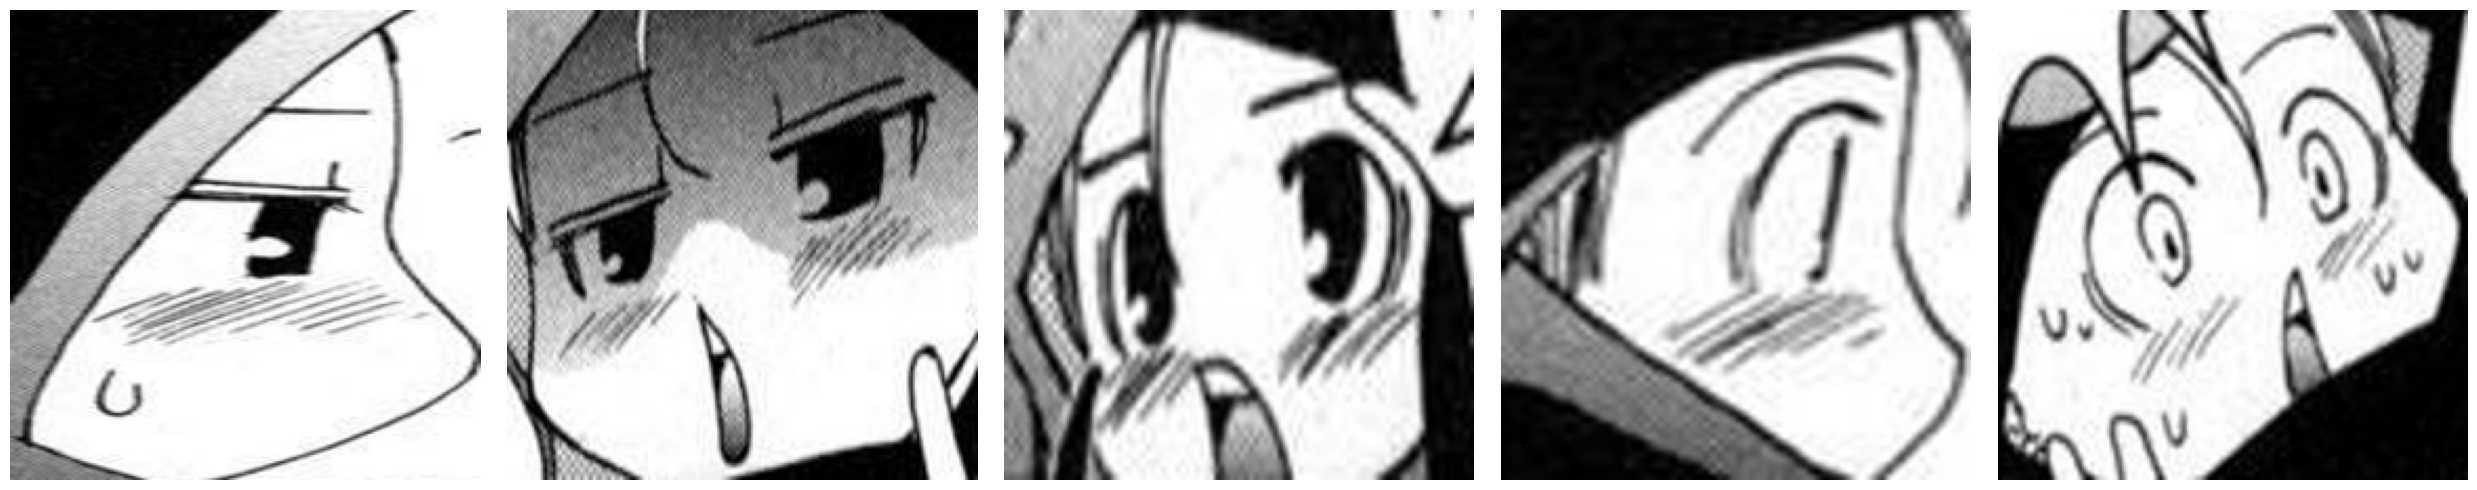

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

num_show = 5
# Create subplots
fig, axes = plt.subplots(1, num_show, figsize=(5*num_show, 5))

for i in range(num_show):
    axes[i].imshow(face_imgs[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [8]:
loc = get_location(annotations, 'face')
pprint.pprint(loc)
print(loc.keys())

{0: [],
 1: [{'character': '00002d03', 'position': (575, 161, 633, 198)},
     {'character': '00002d05', 'position': (246, 632, 354, 835)},
     {'character': '00002d03', 'position': (525, 740, 644, 840)},
     {'character': '00002d05', 'position': (490, 378, 644, 490)},
     {'character': '00002d05', 'position': (210, 153, 306, 219)}],
 2: [{'character': '00002d03', 'position': (525, 410, 614, 472)},
     {'character': '00002d05', 'position': (957, 975, 1029, 1056)},
     {'character': '00002d03', 'position': (662, 984, 709, 1011)},
     {'character': '00002d03', 'position': (1314, 170, 1466, 266)},
     {'character': '00002d03', 'position': (583, 686, 674, 749)},
     {'character': '00002d05', 'position': (111, 703, 228, 805)},
     {'character': '00002d05', 'position': (608, 216, 704, 274)},
     {'character': '00002d05', 'position': (1434, 677, 1464, 709)},
     {'character': '00002d03', 'position': (974, 141, 1052, 190)},
     {'character': '00002d03', 'position': (242, 743, 355, 

In [10]:
pil_image_data = create_data(DATASET_PATH, annotations)
print(len(pil_image_data))


25


In [16]:
# Create batch for first character
x = data_tensor_loader(pil_image_data[0]['face_imgs'], simple_transform)
list_x = list(x)
print(len(list_x))

stacked_x = torch.vstack(list_x)
print(stacked_x.shape)

Load Cropped data:   0%|          | 0/349 [00:00<?, ?img/s]

Load Cropped data: 100%|██████████| 349/349 [00:02<00:00, 126.02img/s]


6
torch.Size([349, 3, 224, 224])
